In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
import random
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras import regularizers
from keras.callbacks import EarlyStopping

In [2]:
# Load dataset
df = pd.read_csv("Awake_Data.csv", header=0)

df

,5,10,15,20,25,30,35,40
0,0.138161,0.066419,0.088474,-0.211050,-0.263519,0.019489,-0.032790,0.332438
1,-0.032220,0.055066,0.314811,-0.484039,-0.314018,0.300224,0.521628,-0.068489
2,0.489065,0.093884,0.069215,0.120450,-0.104660,0.085914,0.221154,0.507176
3,0.265273,0.182474,0.075563,0.277022,-0.072290,-0.164319,0.135967,-0.074133
4,0.201336,0.083792,0.027693,-0.143447,0.112110,0.252779,0.238875,0.229935
...,...,...,...,...,...,...,...,...
6225,0.399811,0.310603,0.284511,0.252620,0.068218,0.114523,0.501512,0.310495
6226,0.210951,0.368503,0.232938,0.210696,0.253603,0.300165,0.390003,0.307180
6227,0.804792,0.473315,0.190585,0.873211,0.354485,0.712021,0.359622,0.679737
6228,0.600947,0.479804,0.200416,0.301992,0.166030,0.232328,0.151917,0.123435


### Putting in loop to make heatmap

In [3]:
cluster_array = [50,100,150,200,250,300,350,400,450,500,550,600,650,700,750,800,850,900,950,1000]
size_array = [50,100,150,200,250,300,350,400,450,500,550,600,650,700,750,800,850,900,950,1000]

In [4]:
def create_heatmap(cluster,number):
    num_clusters = cluster
    cluster_size = number
    num_samples = num_clusters * cluster_size
    resampled_df = df.sample(n=num_samples, replace=True, random_state = 42).reset_index(drop=True)

    shuf_mat = resampled_df.T.to_numpy()

    y = []
    values = list(range(8))  # Generates [0, 1, 2, 3, 4, 5, 6, 7]

    for value in values:
        y.extend([value] * num_clusters)  
    y = np.array(y)

    x = []

    for k in range(8):
        for j in range(num_clusters):
            temp = []
            start_idx = j * cluster_size  
            for i in range(cluster_size):
                temp.append(shuf_mat[k][start_idx+i]) 
            x.append(temp) 
    X = np.array(x)

    #Best: 0.3 test size, 50 epochs, batch size 32
    # Define dataset parameters
    num_groups = 8  
    group_size = num_clusters  
    num_features = cluster_size  
    
    random.seed(42)
    np.random.seed(42)
    tf.random.set_seed(42)
    
    # Create group IDs (0-7, each repeated 70 times)
    group_labels = np.repeat(np.arange(num_groups), group_size)  
    
    # Split data while preserving group structure
    X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
        X, y, group_labels, test_size=0.3, random_state=42, stratify=group_labels
    )
    
    # Standardize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Convert labels to categorical (one-hot encoding)
    y_train_categorical = keras.utils.to_categorical(y_train, len(np.unique(y)))
    y_test_categorical = keras.utils.to_categorical(y_test, num_classes=8)
    
    
    # Build ANN model
    model = Sequential([
        Dense(128, activation='sigmoid', input_shape=(num_features,),kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(8, activation='softmax')  # 8 output classes
    ])
    
    # Define EarlyStopping callback
    early_stop = EarlyStopping(
        monitor='val_loss',       # what to monitor
        patience=10,               # how many epochs to wait after last improvement
        restore_best_weights=True # restore model weights from the best epoch
    )
    
    
    #.425 = .35 acc
    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Train the model
    #history = model.fit(X_train, y_train_categorical, epochs=100, batch_size=32, validation_data=(X_test, y_test_categorical))
    history = model.fit(X_train, y_train_categorical, epochs=100, batch_size=32,validation_data=(X_test, y_test_categorical),callbacks=[early_stop])
    
    # Make predictions
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Evaluate model performance
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)
    
    return accuracy



In [5]:
accuracy_heatmap = []
for c in range(len(cluster_array)):
    for d in range(len(size_array)):
        acc_value = create_heatmap(cluster_array[c],size_array[d])
        accuracy_heatmap.append(acc_value)
        

Epoch 1/100


/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0963 - loss: 2.3081 - val_accuracy: 0.0917 - val_loss: 2.1439
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1419 - loss: 2.1668 - val_accuracy: 0.1167 - val_loss: 2.1414
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1218 - loss: 2.1595 - val_accuracy: 0.1750 - val_loss: 2.1329
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1228 - loss: 2.1499 - val_accuracy: 0.2000 - val_loss: 2.1243
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1396 - loss: 2.1397 - val_accuracy: 0.2250 - val_loss: 2.1174
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1278 - loss: 2.1509 - val_accuracy: 0.2500 - val_loss: 2.1083
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1897 - loss: 2.1438 - val_accuracy: 0.3000 - val_loss: 2.0929
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1556 - loss: 2.1181 - val_accuracy: 0.2750 - val_loss: 2.0743
Epoch 9/100

/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0972 - loss: 2.3514 - val_accuracy: 0.1167 - val_loss: 2.2105
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1637 - loss: 2.2013 - val_accuracy: 0.1000 - val_loss: 2.1980
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1442 - loss: 2.1841 - val_accuracy: 0.1250 - val_loss: 2.1886
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1475 - loss: 2.1853 - val_accuracy: 0.1417 - val_loss: 2.1793
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1970 - loss: 2.1507 - val_accuracy: 0.1833 - val_loss: 2.1626
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2409 - loss: 2.1574 - val_accuracy: 0.2167 - val_loss: 2.1351
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1719 - loss: 2.1437 - val_accuracy: 0.2167 - val_loss: 2.1115
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2395 - loss: 2.0757 - val_accuracy: 0.2250 - val_loss: 2.0737
Epoch 9/100

...

175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2484 - loss: 2.0659 - val_accuracy: 0.5108 - val_loss: 1.3851
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4926 - loss: 1.3426 - val_accuracy: 0.5575 - val_loss: 1.3085
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5557 - loss: 1.1607 - val_accuracy: 0.5479 - val_loss: 1.3397
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5792 - loss: 1.0774 - val_accuracy: 0.5629 - val_loss: 1.3396
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5902 - loss: 1.0376 - val_accuracy: 0.5671 - val_loss: 1.3638
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6129 - loss: 0.9745 - val_accuracy: 0.5492 - val_loss: 1.4054
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6155 - loss: 0.9562 - val_accuracy: 0.5542 - val_loss: 1.4057
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6247 - loss: 0.9468 - val_accuracy: 0.5504

/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

Epoch 1/100


/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2356 - loss: 2.0751 - val_accuracy: 0.5129 - val_loss: 1.3934
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4785 - loss: 1.3645 - val_accuracy: 0.5742 - val_loss: 1.2679
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5355 - loss: 1.1618 - val_accuracy: 0.5671 - val_loss: 1.2828
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5636 - loss: 1.0947 - val_accuracy: 0.5746 - val_loss: 1.3071
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6046 - loss: 1.0124 - val_accuracy: 0.5704 - val_loss: 1.3523
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5970 - loss: 0.9890 - val_accuracy: 0.5658 - val_loss: 1.3616
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6050 - loss: 0.9533 - val_accuracy: 0.5675 - val_loss: 1.3917
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6299 - loss: 0.9131 - val_accuracy: 0.5579

In [6]:
print(accuracy_heatmap)

[0.4, 0.3333333333333333, 0.3333333333333333, 0.425, 0.325, 0.35, 0.375, 0.425, 0.38333333333333336, 0.3416666666666667, 0.3333333333333333, 0.31666666666666665, 0.35, 0.31666666666666665, 0.3416666666666667, 0.275, 0.3333333333333333, 0.23333333333333334, 0.275, 0.23333333333333334, 0.275, 0.375, 0.45, 0.43333333333333335, 0.4375, 0.4375, 0.45, 0.425, 0.4625, 0.4375, 0.45, 0.4708333333333333, 0.42083333333333334, 0.4083333333333333, 0.45, 0.4375, 0.42083333333333334, 0.42083333333333334, 0.36666666666666664, 0.45416666666666666, 0.3277777777777778, 0.38055555555555554, 0.4, 0.44166666666666665, 0.4777777777777778, 0.4638888888888889, 0.46944444444444444, 0.5083333333333333, 0.5111111111111111, 0.5083333333333333, 0.49444444444444446, 0.49722222222222223, 0.4861111111111111, 0.5027777777777778, 0.4888888888888889, 0.4638888888888889, 0.49444444444444446, 0.4888888888888889, 0.44166666666666665, 0.46944444444444444, 0.30625, 0.37083333333333335, 0.44166666666666665, 0.47291666666666665,

In [7]:
reshaped = np.reshape(accuracy_heatmap,(20,20))

In [8]:
print(reshaped)

[[0.4        0.33333333 0.33333333 0.425      0.325      0.35
  0.375      0.425      0.38333333 0.34166667 0.33333333 0.31666667
  0.35       0.31666667 0.34166667 0.275      0.33333333 0.23333333
  0.275      0.23333333]
 [0.275      0.375      0.45       0.43333333 0.4375     0.4375
  0.45       0.425      0.4625     0.4375     0.45       0.47083333
  0.42083333 0.40833333 0.45       0.4375     0.42083333 0.42083333
  0.36666667 0.45416667]
 [0.32777778 0.38055556 0.4        0.44166667 0.47777778 0.46388889
  0.46944444 0.50833333 0.51111111 0.50833333 0.49444444 0.49722222
  0.48611111 0.50277778 0.48888889 0.46388889 0.49444444 0.48888889
  0.44166667 0.46944444]
 [0.30625    0.37083333 0.44166667 0.47291667 0.45625    0.4875
  0.47708333 0.48958333 0.49375    0.51666667 0.48958333 0.52291667
  0.50208333 0.4875     0.50625    0.52291667 0.525      0.51041667
  0.48958333 0.4875    ]
 [0.29333333 0.41333333 0.44833333 0.45       0.45       0.475
  0.53       0.495      0.505      

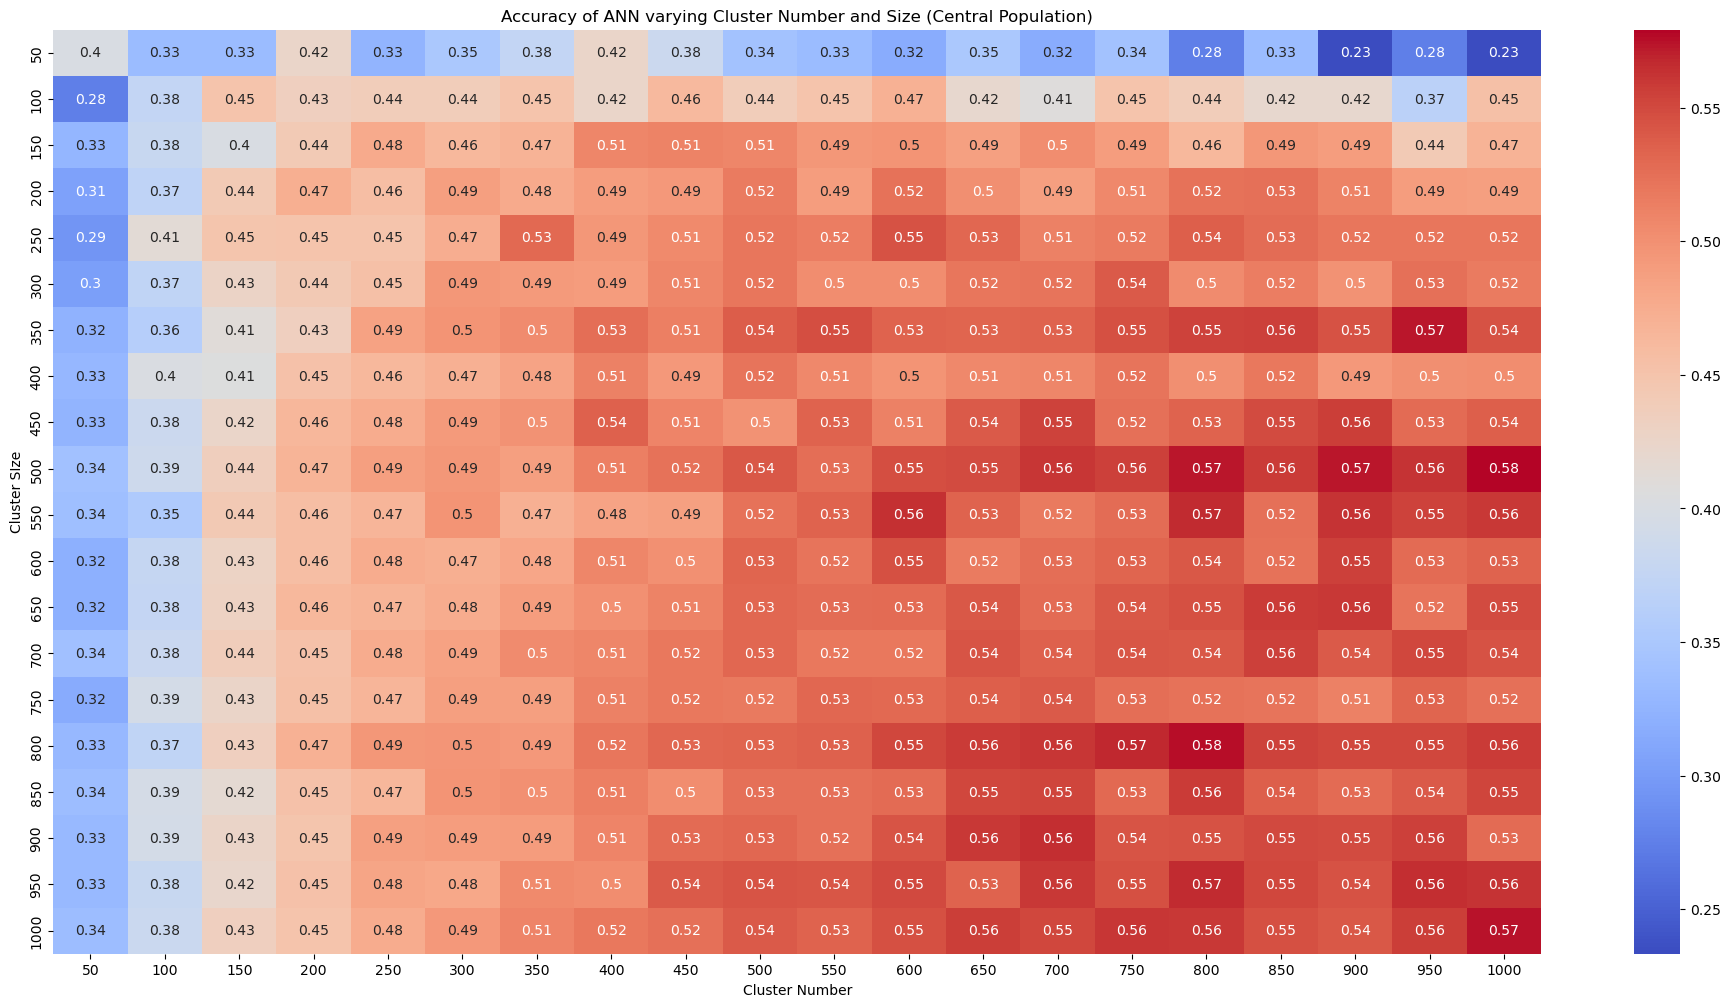

In [10]:
plt.figure(figsize=(24, 12))
sns.heatmap(reshaped, annot=True, annot_kws={"size": 10}, cmap="coolwarm",xticklabels=['50','100','150','200','250','300','350','400','450','500','550','600','650','700','750','800','850','900','950','1000'],
            yticklabels=['50','100','150','200','250','300','350','400','450','500','550','600','650','700','750','800','850','900','950','1000'])
plt.xlabel("Cluster Number")
plt.ylabel("Cluster SIze")
plt.title("Accuracy of ANN varying Cluster Number and Size (Central Population)")
plt.show()

### Single Run at a Time

In [3]:
num_clusters = 80
cluster_size = 90
num_samples = num_clusters * cluster_size
resampled_df = df.sample(n=num_samples, replace=True, random_state = 42).reset_index(drop=True)

In [4]:
resampled_df

,5,10,15,20,25,30,35,40
0,0.145306,0.654103,0.286369,0.185542,0.270558,-0.173551,0.273946,0.400615
1,0.198353,0.354337,0.401526,0.059614,0.092808,0.113003,0.277087,0.109946
2,0.248343,0.445146,0.407544,0.154861,0.153911,0.058942,0.112767,0.077585
3,0.216835,0.259393,0.037710,0.096759,0.121735,0.026651,-0.010712,-0.028317
4,0.230416,0.002492,0.147509,0.318528,0.052261,0.135964,0.021841,0.106572
...,...,...,...,...,...,...,...,...
7195,0.116786,0.080283,0.154090,0.138534,-0.078831,0.125273,0.203382,0.151211
7196,0.229275,0.109895,0.041337,0.029710,-0.064947,-0.045050,0.441954,0.029648
7197,2.143989,1.711297,0.894523,0.639365,0.273498,0.513172,0.366090,0.264515
7198,0.038867,0.208100,0.175544,0.169230,-0.040863,0.063671,0.093041,0.192471


In [5]:
shuf_mat = resampled_df.T.to_numpy()
shuf_mat.shape

(8, 7200)

### Code for Labels after Shuffling

In [6]:
y = []
values = list(range(8))  # Generates [0, 1, 2, 3, 4, 5, 6, 7]

for value in values:
    y.extend([value] * num_clusters)  


In [7]:
y = np.array(y)
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 6
 6 6 6 6 6 6 6 6 6 6 6 6 

In [8]:
len(y)

640

### Code for creating X after Shuffling

In [9]:
x = []

for k in range(8):
    for j in range(num_clusters):
        temp = []
        start_idx = j * cluster_size  
        for i in range(cluster_size):
            temp.append(shuf_mat[k][start_idx+i]) 
        x.append(temp) 
print(len(x))

640


In [10]:
X = np.array(x)
X.shape

(640, 90)

In [11]:
print(X)

[[ 0.14530635  0.1983534   0.2483435  ...  1.2230591   0.02877911
   0.60289096]
 [ 0.19746351  0.34449928  0.24231456 ...  0.21639255  0.30427449
   0.48363187]
 [ 0.1732872   0.47371807  0.09601722 ...  0.08257188  1.15141764
   2.00376711]
 ...
 [ 0.14217089  0.47514575  0.14915881 ...  0.34671232  0.15797878
   0.7656015 ]
 [ 0.31790904 -0.1754471   0.10352192 ...  0.45144139  0.0559263
   0.35331981]
 [ 0.02894731 -0.0850362   0.29229403 ...  0.26451485  0.19247133
  -0.0453397 ]]


### Running ANN with Early Stopping

In [ ]:
#Best: 0.3 test size, 50 epochs, batch size 32
# Define dataset parameters
num_groups = 8  
group_size = num_clusters  
num_features = cluster_size  

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Create group IDs (0-7, each repeated 70 times)
group_labels = np.repeat(np.arange(num_groups), group_size)  

# Split data while preserving group structure
X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    X, y, group_labels, test_size=0.3, random_state=42, stratify=group_labels
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert labels to categorical (one-hot encoding)
y_train_categorical = keras.utils.to_categorical(y_train, len(np.unique(y)))
y_test_categorical = keras.utils.to_categorical(y_test, num_classes=8)


# Build ANN model
model = Sequential([
    Dense(128, activation='sigmoid', input_shape=(num_features,),kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='softmax')  # 8 output classes
])

# Define EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',       # what to monitor
    patience=10,               # how many epochs to wait after last improvement
    restore_best_weights=True # restore model weights from the best epoch
)


#.425 = .35 acc
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
#history = model.fit(X_train, y_train_categorical, epochs=100, batch_size=32, validation_data=(X_test, y_test_categorical))
history = model.fit(X_train, y_train_categorical, epochs=100, batch_size=32,validation_data=(X_test, y_test_categorical),callbacks=[early_stop])

# Make predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

# Plot Confusion Matrix as Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(8), yticklabels=range(8))
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot training history (Accuracy)
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy Over Epochs')
plt.show()

# Plot training history (Loss)
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss Over Epochs')
plt.show()


Epoch 1/50


/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.1232 - loss: 3.0004 - val_accuracy: 0.1250 - val_loss: 2.4571
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.1343 - loss: 2.7041 - val_accuracy: 0.1369 - val_loss: 2.3887
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0938 - loss: 2.7375 - val_accuracy: 0.1488 - val_loss: 2.3821
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1091 - loss: 2.6938 - val_accuracy: 0.1071 - val_loss: 2.3967
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1090 - loss: 2.6465 - val_accuracy: 0.1429 - val_loss: 2.3723
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1197 - loss: 2.6718 - val_accuracy: 0.1429 - val_loss: 2.3162
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1758 - loss: 2.5115 - val_accuracy: 0.2143 - val_loss: 2.2228
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1753 - loss: 2.4440 - val_accuracy: 0.2262 - val_loss: 2.

/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

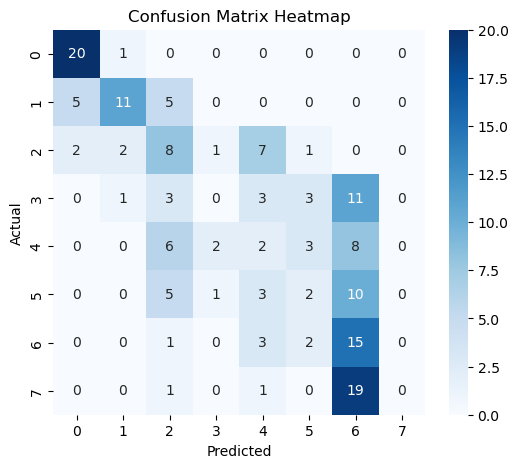

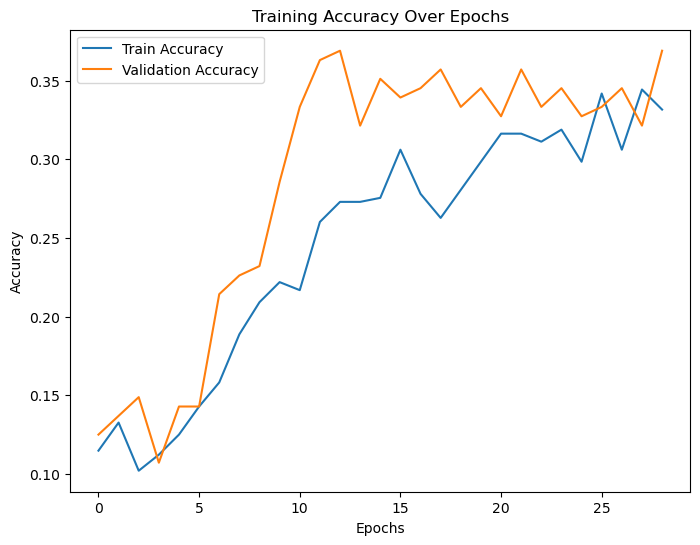

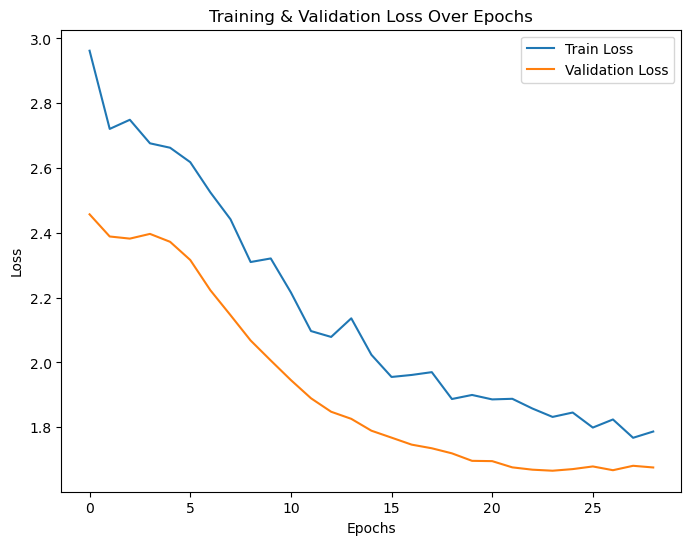

In [12]:
#Best: 0.3 test size, 50 epochs, batch size 32
# Define dataset parameters
num_groups = 8  
group_size = num_clusters  
num_features = cluster_size  

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Create group IDs (0-7, each repeated 70 times)
group_labels = np.repeat(np.arange(num_groups), group_size)  

# Split data while preserving group structure
X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    X, y, group_labels, test_size=0.3, random_state=42, stratify=group_labels
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert labels to categorical (one-hot encoding)
y_train_categorical = keras.utils.to_categorical(y_train, len(np.unique(y)))
y_test_categorical = keras.utils.to_categorical(y_test, num_classes=8)


# Build ANN model
model = Sequential([
    Dense(128, activation='sigmoid', input_shape=(num_features,),kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(32, activation='relu',kernel_regularizer=regularizers.l2(0.001)),
    Dense(16, activation='relu',kernel_regularizer=regularizers.l2(0.001)),
    Dense(8, activation='softmax')  # 8 output classes
])

# Define EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',       # what to monitor
    patience=5,               # how many epochs to wait after last improvement
    restore_best_weights=True # restore model weights from the best epoch
)

#.425 = .35 acc
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
#history = model.fit(X_train, y_train_categorical, epochs=50, batch_size=32, validation_data=(X_test, y_test_categorical))
# Train the model with early stopping
history = model.fit(
    X_train, y_train_categorical,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test_categorical),
    callbacks=[early_stop]
)

# Make predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

# Plot Confusion Matrix as Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(8), yticklabels=range(8))
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot training history (Accuracy)
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy Over Epochs')
plt.show()

# Plot training history (Loss)
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss Over Epochs')
plt.show()
